# Exploratory Data Analysis (EDA)

Loads all CSV files from a user-defined folder and performs a structured EDA.

| Section | Content |
|---|---|
| **1. Per-File** | Descriptive stats · Kurtosis & Skewness · Histograms · Correlation matrix |
| **2. Aggregate** | Global stats on concatenated data · Cross-file summary · Aggregate histograms · Correlation matrices |

> Per-file **plots** are capped at `MAX_FILES_DISPLAY` to keep the output manageable.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [15]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
load_from_dir = "../data/SNP500_individual_normalized_post2002"  # <-- set your folder here

# Max files for which per-file PLOTS are rendered (set None to plot all files)
MAX_FILES_DISPLAY = 5

# Remove Black Monday (19 Oct 1987) rows from all loaded dataframes
remove_black_monday = True
# ─────────────────────────────────────────────────────────────────────────────

---
## 0. Data Loading

In [16]:
csv_paths = sorted(Path(load_from_dir).glob("*.csv"))
assert len(csv_paths) > 0, f"No CSV files found in '{load_from_dir}'"

dataframes = {p.stem: pd.read_csv(p, parse_dates=["date"], dayfirst=True) for p in csv_paths}
print(f"Loaded {len(dataframes)} file(s) from '{load_from_dir}'")

if remove_black_monday:
    BLACK_MONDAY = "1987-10-19"
    before = sum(len(df) for df in dataframes.values())
    dataframes = {
        name: df[df["date"] != BLACK_MONDAY].reset_index(drop=True)
        for name, df in dataframes.items()
    }
    removed = before - sum(len(df) for df in dataframes.values())
    print(f"Black Monday ({BLACK_MONDAY}) removed: {removed} row(s) dropped")

# Schema check
schemas = {name: tuple(df.columns.tolist()) for name, df in dataframes.items()}
unique_schemas = set(schemas.values())
if len(unique_schemas) == 1:
    cols = list(unique_schemas)[0]
    print(f"Shared schema ({len(cols)} columns): {cols}")
else:
    print(f"WARNING: {len(unique_schemas)} different schemas detected.")
    for schema in unique_schemas:
        count = sum(1 for v in schemas.values() if v == schema)
        print(f"  {schema}  →  {count} file(s)")

Loaded 354 file(s) from '../data/SNP500_individual_normalized_post2002'
Black Monday (1987-10-19) removed: 0 row(s) dropped
Shared schema (5 columns): ('date', 'close', 'open', 'high', 'low')


---
## 1. Per-File Statistics

For each CSV: descriptive statistics (mean, median, std, min, max), kurtosis, skewness, histograms, and correlation matrix.

### 1.1 Descriptive Statistics per File

In [17]:
summary_rows = []

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    desc   = num_df.describe()
    median = num_df.median().rename('median')
    kurt   = num_df.kurtosis().rename('kurtosis')
    skew   = num_df.skew().rename('skewness')

    extended = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    display(extended)

    # Collect for cross-file summary
    for col in num_df.columns:
        summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     num_df[col].mean(),
            'median':   num_df[col].median(),
            'std':      num_df[col].std(),
            'min':      num_df[col].min(),
            'max':      num_df[col].max(),
            'kurtosis': num_df[col].kurtosis(),
            'skewness': num_df[col].skew(),
        })

per_file_summary = pd.DataFrame(summary_rows)


────────────────────────────────────────────────────────────
  A_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,close,open,high,low
count,6106.0000,6106.0000,6106.0000,6106.0000
mean,-0.0060,-0.0311,-0.0237,0.0068
median,0.0127,-0.0241,-0.1769,0.1865
std,0.9432,0.9329,0.9065,0.9070
min,-12.8182,-12.1654,-6.1580,-14.0866
25%,-0.4354,-0.3621,-0.5337,-0.3035
50%,0.0127,-0.0241,-0.1769,0.1865
75%,0.4550,0.2997,0.2982,0.5087
max,8.8987,9.5216,11.8339,6.0828
kurtosis,10.8345,28.2046,13.2445,18.1882



────────────────────────────────────────────────────────────
  AAPL_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,close,open,high,low
count,6106.0000,6106.0000,6106.0000,6106.0000
mean,0.0286,0.0380,0.0098,0.0428
median,0.0250,0.0481,-0.1387,0.2098
std,0.9435,1.0454,0.9069,0.9351
min,-8.8550,-12.0946,-8.1614,-12.2596
25%,-0.4162,-0.3506,-0.4837,-0.3065
50%,0.0250,0.0481,-0.1387,0.2098
75%,0.5102,0.4377,0.3487,0.5606
max,6.3611,9.6825,7.8731,5.7368
kurtosis,5.9065,22.4319,11.2312,18.8678



────────────────────────────────────────────────────────────
  ABBV_2013-01-02_2026-04-10
────────────────────────────────────────────────────────────


...

,close,open,high,low
count,6106.0000,6106.0000,6106.0000,6106.0000
mean,-0.0052,-0.0131,0.0238,-0.0394
median,0.0017,-0.0101,-0.1394,0.1457
std,0.8499,0.7200,0.8114,0.7998
min,-6.3188,-10.9404,-3.7257,-10.0293
25%,-0.4162,-0.2820,-0.4512,-0.3322
50%,0.0017,-0.0101,-0.1394,0.1457
75%,0.4027,0.2722,0.3061,0.4319
max,8.5125,8.8966,10.9167,5.9090
kurtosis,6.3250,33.6674,17.5104,16.1737



────────────────────────────────────────────────────────────
  XOM_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,close,open,high,low
count,6106.0000,6106.0000,6106.0000,6106.0000
mean,-0.0042,-0.0149,-0.1668,0.1560
median,0.0012,-0.0109,-0.2711,0.2760
std,0.7352,0.7555,0.7035,0.7127
min,-6.7432,-10.9176,-4.4309,-8.8867
25%,-0.3609,-0.3206,-0.5644,-0.0871
50%,0.0012,-0.0109,-0.2711,0.2760
75%,0.3691,0.3293,0.1128,0.5685
max,7.0776,8.5374,8.5452,5.5583
kurtosis,9.2326,22.8937,15.6564,19.8261



────────────────────────────────────────────────────────────
  XYZ_2015-11-19_2026-04-10
────────────────────────────────────────────────────────────


,close,open,high,low
count,2610.0000,2610.0000,2610.0000,2610.0000
mean,0.0069,0.0188,0.5039,-0.4594
median,0.0554,0.0796,0.3018,-0.1388
std,1.6227,1.7354,1.5590,1.6255
min,-15.0680,-20.7431,-12.7519,-18.2864
25%,-0.7889,-0.5702,-0.3502,-1.0887
50%,0.0554,0.0796,0.3018,-0.1388
75%,0.8305,0.6646,1.1055,0.4670
max,10.3700,15.4477,12.5114,8.0527
kurtosis,6.8356,23.7375,10.4453,15.4575


### 1.2 Per-File Histograms
> Limited to the first `MAX_FILES_DISPLAY` files.

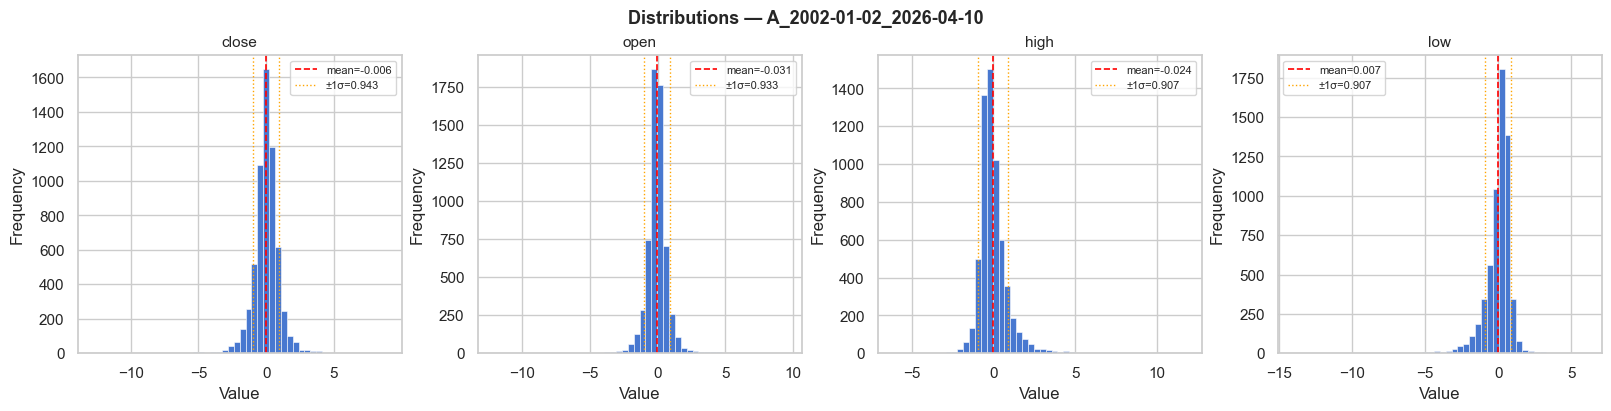

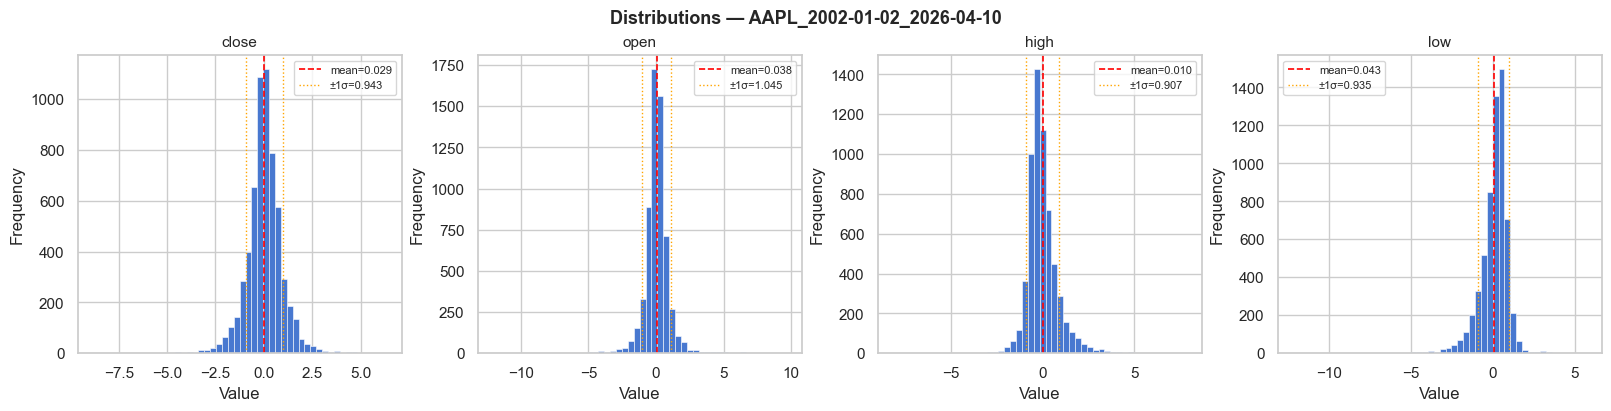

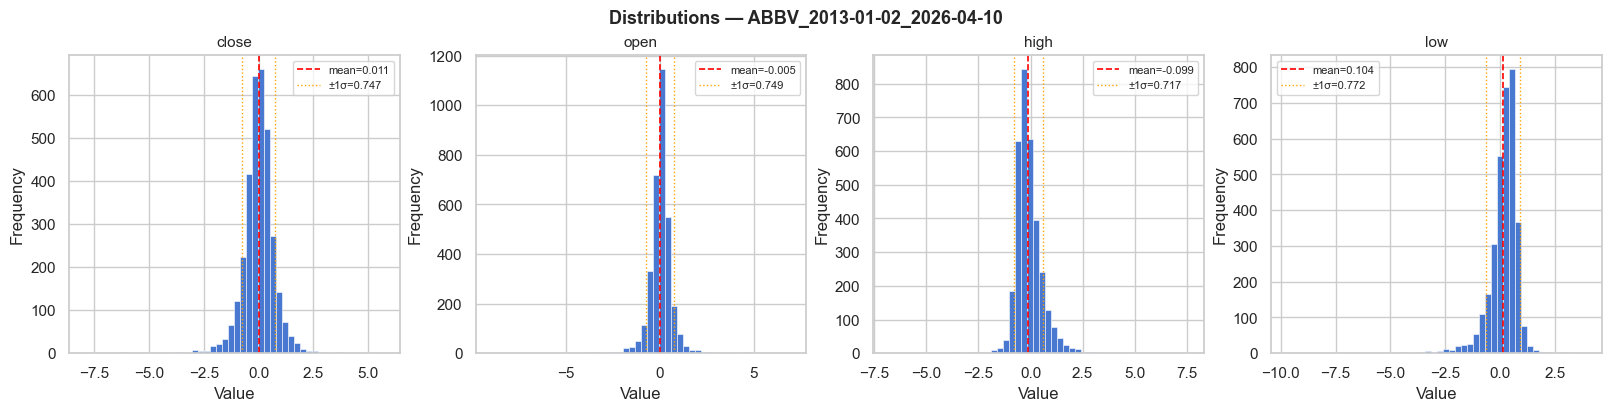

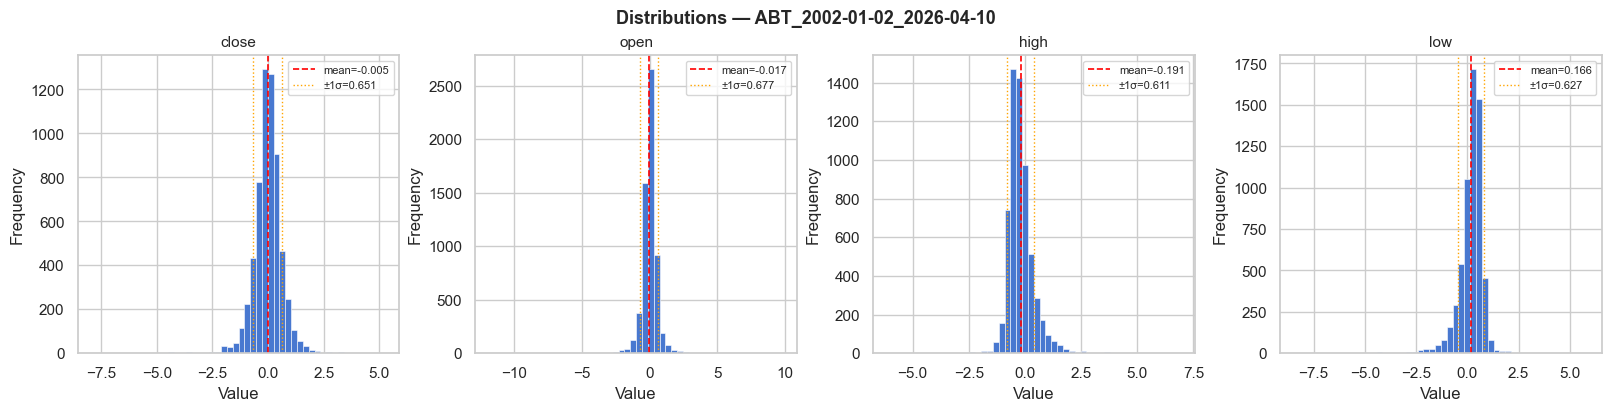

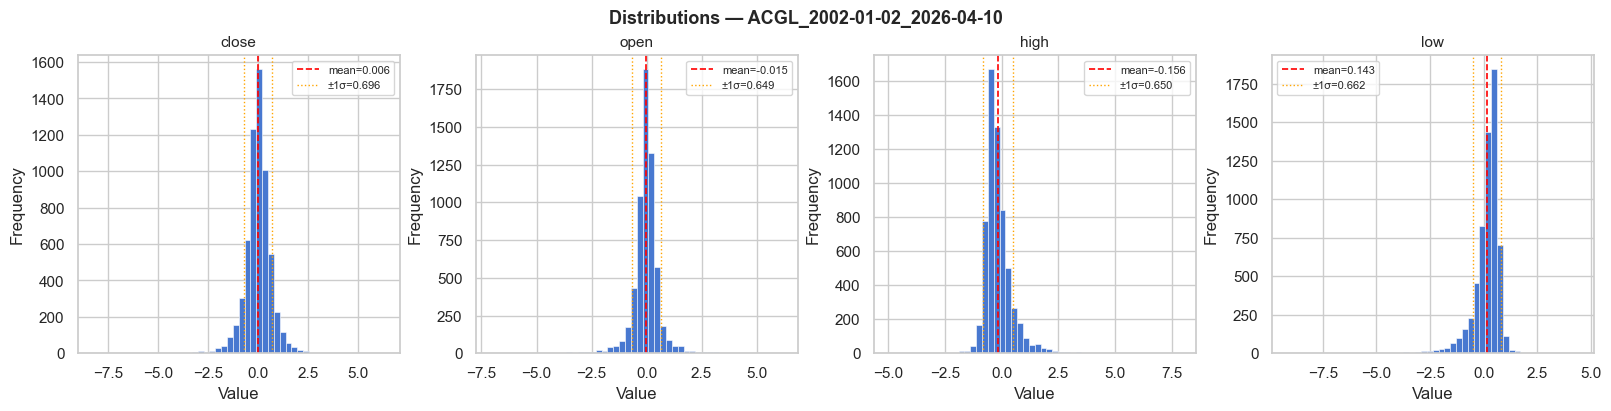

In [18]:
plot_items = list(dataframes.items())
if MAX_FILES_DISPLAY is not None:
    plot_items = plot_items[:MAX_FILES_DISPLAY]

for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    n_cols = len(num_df.columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, num_df.columns):
        data = num_df[col].dropna()
        ax.hist(data, bins=50, edgecolor='white', linewidth=0.4)
        mu, sigma = data.mean(), data.std()
        ax.axvline(mu, color='red',    linestyle='--', linewidth=1.2, label=f'mean={mu:.3f}')
        ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.0)
        ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.0, label=f'\u00b11\u03c3={sigma:.3f}')
        ax.set_title(col, fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    fig.suptitle(f"Distributions \u2014 {name}", fontsize=13, fontweight='bold')
    plt.show()

### 1.3 Per-File Correlation Matrix
> Limited to the first `MAX_FILES_DISPLAY` files.

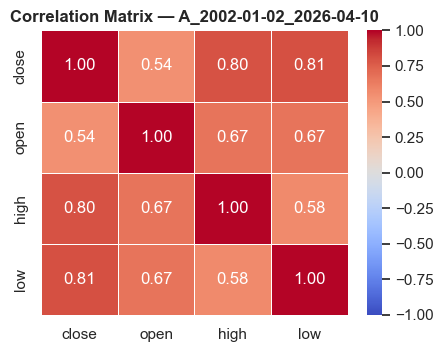

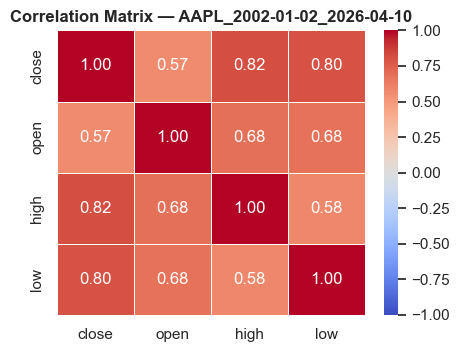

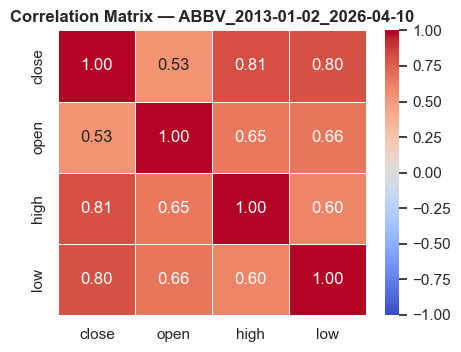

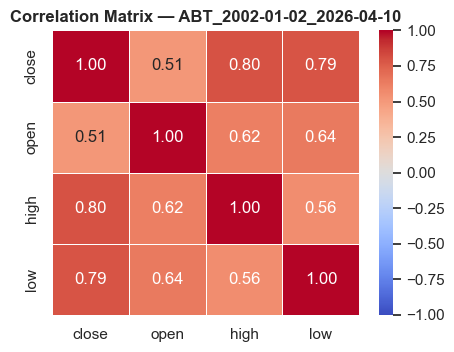

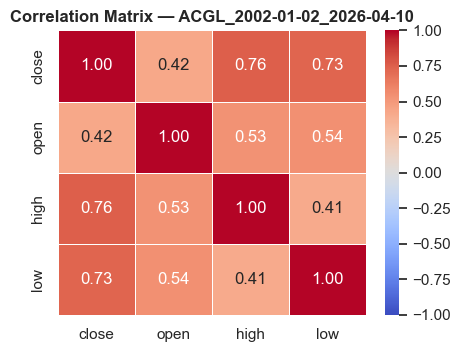

In [19]:
for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.shape[1] < 2:
        print(f"{name}: only one numeric column, correlation skipped.")
        continue

    corr = num_df.corr()
    size = max(4, len(corr) * 0.9 + 1)
    fig, ax = plt.subplots(figsize=(size, size * 0.8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f"Correlation Matrix \u2014 {name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 2. Aggregate Statistics

Statistics computed over **all files combined** (rows from every CSV concatenated).
The cross-file summary shows per-column statistics averaged across files, giving a
sense of how consistent individual files are relative to the global distribution.

### 2.1 Aggregate Descriptive Statistics

In [20]:
# Build combined dataset on the intersection of numeric columns
common_cols = sorted(
    set.intersection(*[set(df.select_dtypes(include='number').columns)
                       for df in dataframes.values()])
)
combined_df = pd.concat(
    [df[common_cols] for df in dataframes.values()],
    ignore_index=True
)
print(f"Combined dataset: {len(combined_df):,} rows x {len(common_cols)} columns")
print(f"Columns: {common_cols}\n")

# Extended describe
desc   = combined_df.describe()
median = combined_df.median().rename('median')
kurt   = combined_df.kurtosis().rename('kurtosis')
skew   = combined_df.skew().rename('skewness')

agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order  = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
agg_stats  = agg_stats.reindex([r for r in row_order if r in agg_stats.index])

print("Aggregate Descriptive Statistics (all files combined):")
display(agg_stats)

Combined dataset: 1,934,336 rows x 4 columns
Columns: ['close', 'high', 'low', 'open']

Aggregate Descriptive Statistics (all files combined):


,close,high,low,open
count,1934336.0000,1934336.0000,1934336.0000,1934336.0000
mean,-0.0000,0.0000,-0.0000,0.0000
median,0.0084,-0.1899,0.2005,-0.0063
std,1.0000,1.0000,1.0000,1.0000
min,-41.9095,-42.6799,-68.2214,-76.8637
25%,-0.4104,-0.5088,-0.2662,-0.2994
50%,0.0084,-0.1899,0.2005,-0.0063
75%,0.4256,0.2826,0.5068,0.3190
max,31.5171,43.5377,27.7978,48.2581
kurtosis,31.7767,51.8149,92.0870,128.9460


### 2.2 Cross-File Summary

Mean and standard deviation of each per-file statistic, grouped by column.
High std values indicate heterogeneity across files.

In [21]:
cross_file = (
    per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
cross_file.columns = [f"{stat}_{agg}" for stat, agg in cross_file.columns]
display(cross_file)

,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
close,0.0009,0.0126,0.0097,0.0189,0.9863,0.3034,-11.4022,5.8245,9.2311,4.0500,19.2320,26.4178,-0.4903,0.9179
high,0.0207,0.2183,-0.1491,0.1630,0.9638,0.3230,-8.6395,5.1537,12.4860,6.0982,28.9828,34.2772,2.3148,1.4319
low,-0.0173,0.1949,0.1646,0.1503,0.9700,0.2977,-15.7593,8.1416,6.3252,3.3171,50.4691,80.4731,-3.7128,2.3183
open,0.0017,0.0297,0.0005,0.0248,0.9828,0.3415,-15.8360,8.7107,12.0968,6.6416,62.4922,96.0415,-1.3488,2.7687


### 2.3 Aggregate Histograms

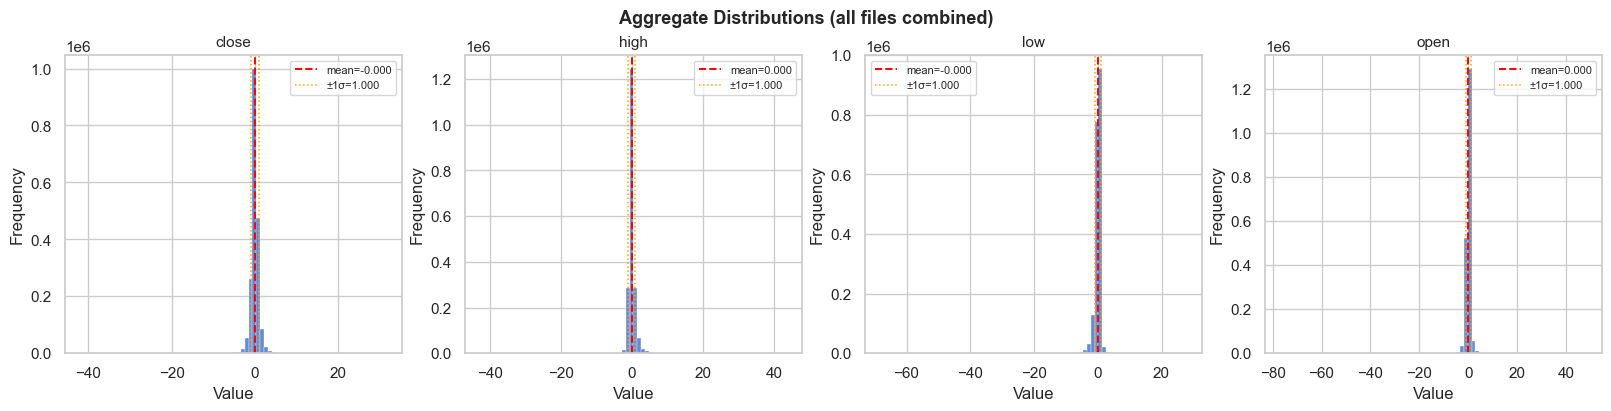

In [22]:
n_cols = len(common_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    data = combined_df[col].dropna()
    ax.hist(data, bins=80, edgecolor='white', linewidth=0.3, alpha=0.85)
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red',    linestyle='--', linewidth=1.4, label=f'mean={mu:.3f}')
    ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.1)
    ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.1, label=f'\u00b11\u03c3={sigma:.3f}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle("Aggregate Distributions (all files combined)", fontsize=13, fontweight='bold')
plt.show()

### 2.4 Aggregate Correlation Matrices

Two complementary views:
- **Left** — correlation computed on the full concatenated dataset
- **Right** — element-wise mean of per-file correlation matrices (preserves within-file structure)

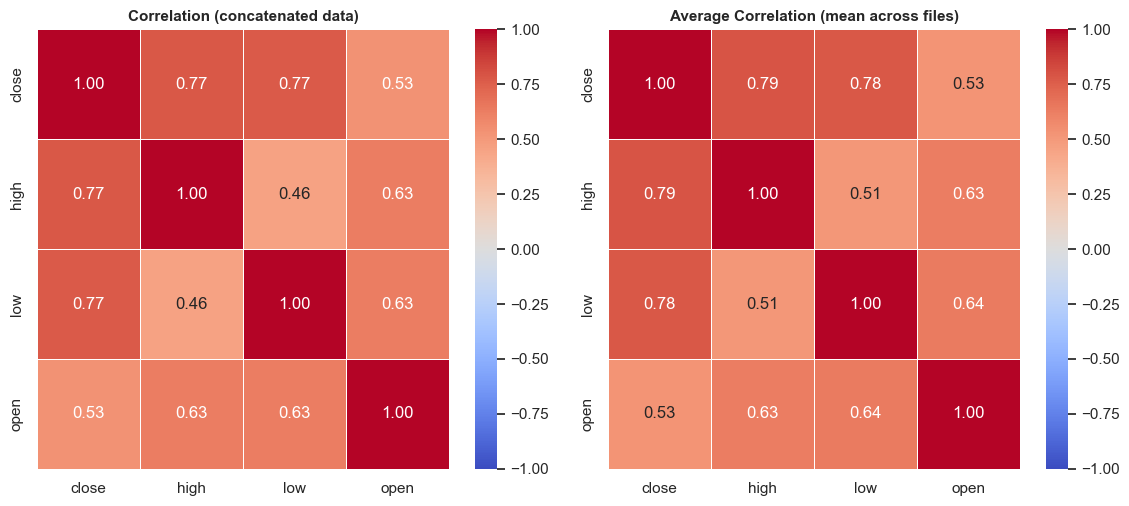

In [23]:
# Per-file correlation matrices stacked
corr_stack = np.array([
    df[common_cols].corr().values
    for df in dataframes.values()
    if df[common_cols].shape[0] > 1
])
avg_corr = pd.DataFrame(corr_stack.mean(axis=0), index=common_cols, columns=common_cols)

size = max(5, len(common_cols) * 1.2 + 1)
fig, axes = plt.subplots(1, 2, figsize=(size * 2, size * 0.9))

# Left: concatenated
corr_combined = combined_df.corr()
sns.heatmap(corr_combined, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlation (concatenated data)", fontsize=11, fontweight='bold')

# Right: average across files
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Average Correlation (mean across files)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()